### Introduction to Artificial Intelligence
## Lab 3
This lab covers Model Based Agents and Goal Based Agents using Uninformed Searches.

#### Section I
* Model Based Reflex Agent
####  Section II
Goal Based Agent
* Depth First Search
* Breadth First Search




### Model Based Agents

**Exercise:** \
A smart elevator operates in a multi-floor building. The elevator receives percepts about the current floor and whether there are people waiting on the current floor. Design a model-based agent that maintains an internal record of floors where people have requested the elevator. When a request is detected, the agent should remember that floor even after it leaves the floor. The agent should use its stored requests to decide which floor to visit next. If there are no pending requests, the elevator should remain at its current floor. Implement the agent in Python and demonstrate how its internal state changes as new requests are detected.

Hint: you can store the internal state like this 

Pending requests = [2,5,7] \
Current floor = 3

In [14]:
environment_status = {
    'pending_requests' : [2, 5, 7],
}

def smartElevator(floor, total_floors = 7):
    if floor < 1 or floor > total_floors:
        print("Invalid Floor")
        return

    pending_list = environment_status.get('pending_requests', [])
    is_crowded = floor in pending_list

    if floor == total_floors:
        next_floor = floor - 1
    else:
        next_floor = floor + 1

    if is_crowded:
        print(f"Picking People and moving to floor: {next_floor}!")
    else:
        print(f"No prople at floor {floor}, moving to {next_floor}")

smartElevator(2)

Picking People and moving to floor: 3!


**Exercise:**
A smart classroom contains an AI system that monitors room conditions. The system receives occasional information about temperature, number of students, and projector status. Design a model-based agent that maintains the latest known state of the classroom. If the temperature becomes high, it should turn on the air conditioner. If the classroom becomes empty, it should turn off unnecessary equipment. If the projector is currently unavailable but the agent remembers that a lecture is in progress, it should notify the instructor. The agent should continue using its stored information even when some percepts are temporarily unavailable.

In [13]:
class SmartClassroomAgent:
    def __init__(self):
        
        self.state = {
            'temperature': 25.0,
            'num_students': 0,
            'projector_status': 'available',
            'lecture_in_progress': False
        }

    def update_state(self, temp=None, students=None, projector=None):
        
        if temp is not None:
            self.state['temperature'] = temp
        if students is not None:
            self.state['num_students'] = students
        if projector is not None:
            self.state['projector_status'] = projector

        
        if self.state['num_students'] > 0:
            self.state['lecture_in_progress'] = True
        else:
            self.state['lecture_in_progress'] = False

    def act(self):
        
        temp = self.state['temperature']
        if temp >= 30:
            print(f"AC ON: Temperature high ({temp}°C).")
        elif temp <= 20:
            print(f"AC OFF: Temperature low/normal ({temp}°C).")

        
        if self.state['num_students'] == 0:
            print("POWER SAVER: Classroom is empty. Turning off lights, AC, and fans.")

        
        if self.state['projector_status'] == 'unavailable' and self.state['lecture_in_progress']:
            print("ALERT: Projector unavailable during an active lecture! Notifying instructor.")

agent = SmartClassroomAgent()

agent.update_state(temp=32, students=25, projector='unavailable')
agent.act()

print("-" * 40)

agent.update_state(temp=None) 
agent.act()

AC ON: Temperature high (32°C).
ALERT: Projector unavailable during an active lecture! Notifying instructor.
----------------------------------------
AC ON: Temperature high (32°C).
ALERT: Projector unavailable during an active lecture! Notifying instructor.


In [14]:
def smartClassroom(temperature = 0.0, is_students = False, projector_status = False):
    if temperature < 1 or temperature > 50:
        print("Invalid Temperature")
        return

    if is_students == False:
        print("No Students Found in class room, \n" \
        "Turning off all Lights, fans and air conditioners")

    if projector_status == False and is_students == True:
        print("Projector is off but students are here, no action is performing")

    if temperature <= 20:
        print(f"Turning off air conditioners due to decrease in temperature: {temperature}")

    if temperature >= 30:
        print(f'Turning on Air Conditioners due to increase in temperature: {temperature}')

smartClassroom(30, True, False)

Projector is off but students are here, no action is performing
Turning on Air Conditioners due to increase in temperature: 30


**Exercise 1**\
Consider the following maze. The Start is marked by S whereas G is the goal. The path the agent can follow is marked by empty spaces. # are the walls.
Implement DFS and BFS for this maze and display the following:
* Path found by DFS
* Path found by BFS
* Number of cells explored
* Length of final path 

`Note`: Solve the maze on your registers too for DFS and BFS and attach the scanned pdf.

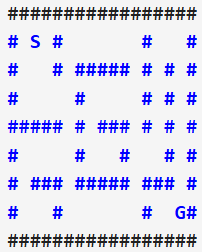

In [ ]:
maze = [
    ["#","#","#","#","#","#","#","#","#","#","#","#"],
    ["#"," ","S"," ","#"," "," "," "," ","#"," ","#"],
    ["#"," "," ","#"," ","#","#","#","#"," ","#"," "],
    ["#"," "," "," ","#"," "," "," "," ","#"," ","#"],
    ["#","#","#","#","#"," ","#","#","#"," ","#"," "],
    ["#"," "," "," "," ","#"," "," ","#"," ","#"," "],
    ["#"," ","#","#","#"," ","#","#","#","#","#"," ","#"],
    ["#"," "," ","#"," "," "," "," "," ","#"," ","G","#"],
    ["#","#","#","#","#","#","#","#","#","#","#","#"]
]

height = len(maze)
width = len(maze[0])

start_pos = (1, 2)
goal_pos = (7, 11)

class Node:
    def __init__(self, state, parent=None, action=None):
        self.state = state
        self.parent = parent
        self.action = action

class StackFrontier:
    def __init__(self):
        self.frontier = []

    def add(self, node):
        self.frontier.append(node)

    def contains_state(self, state):
        return any(node.state == state for node in self.frontier)

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("Empty frontier")
        else:
            return self.frontier.pop()

class QueueFrontier(StackFrontier):
    def remove(self):
        if self.empty():
            raise Exception("Empty frontier")
        else:
            return self.frontier.pop(0)

def get_neighbors(state):
    row, col = state
    candidates = [
        ((row - 1, col), "up"),
        ((row + 1, col), "down"),
        ((row, col - 1), "left"),
        ((row, col + 1), "right")
    ]
    
    valid_neighbors = []
    for (r, c), action in candidates:
        if 0 <= r < height and 0 <= c < width and maze[r][c] != "#":
            valid_neighbors.append(((r, c), action))
            
    return valid_neighbors

def solve_maze(algorithm="DFS"):
    start = Node(state=start_pos, parent=None, action=None)
    
    if algorithm == "DFS":
        frontier = StackFrontier()
    else:
        frontier = QueueFrontier()
        
    frontier.add(start)
    
    explored = set()
    num_explored = 0

    while True:
        if frontier.empty():
            print("No Solution Found!")
            return

        node = frontier.remove()
        num_explored += 1

        if node.state == goal_pos:
            actions = []
            cells = []
            while node.parent is not None:
                actions.append(node.action)
                cells.append(node.state)
                node = node.parent
            actions.reverse()
            cells.reverse()
            
            print(f"=== {algorithm} Results ===")
            print(f"Path Found: {cells}")
            print(f"Number of cells explored: {num_explored}")
            print(f"Length of final path: {len(cells)}")
            return

        explored.add(node.state)

        for state, action in get_neighbors(node.state):
            if state not in explored and not frontier.contains_state(state):
                child = Node(state=state, parent=node, action=action)
                frontier.add(child)

solve_maze("DFS")
print("-" * 40)
solve_maze("BFS")

**Exercise 2**\
Consider the following graph for a hospital. The Start is marked by Reception. If pharmacy is the goal then determine the following. 
* Path found by DFS
* Path found by BFS
* Number of cells explored
* Length of final path 
    
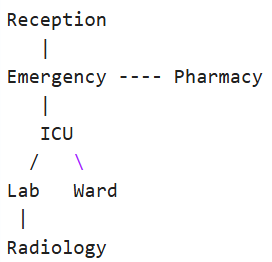 

`

In [ ]:
graph = {
    'Reception': ['Emergency'],
    'Emergency': ['Pharmacy', 'ICU'],
    'Pharmacy': [],
    'ICU': ['Lab', 'Ward'],
    'Lab': ['Radiology'],
    'Ward': [],
    'Radiology': []
}

start_node = 'Reception'
goal_node = 'Pharmacy'

def solve_bfs():
    queue = [[start_node]]
    explored = set()
    num_explored = 0

    while queue:
        path = queue.pop(0)
        node = path[-1]

        if node in explored:
            continue

        explored.add(node)
        num_explored += 1

        if node == goal_node:
            print("=== BFS Results ===")
            print(f"Path found by BFS: {' -> '.join(path)}")
            print(f"Number of nodes explored: {num_explored}")
            print(f"Length of final path: {len(path) - 1} edges ({len(path)} nodes)")
            return

        for neighbor in graph.get(node, []):
            if neighbor not in explored:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

def solve_dfs():
    stack = [[start_node]]
    explored = set()
    num_explored = 0

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in explored:
            continue

        explored.add(node)
        num_explored += 1

        if node == goal_node:
            print("=== DFS Results ===")
            print(f"Path found by DFS: {' -> '.join(path)}")
            print(f"Number of nodes explored: {num_explored}")
            print(f"Length of final path: {len(path) - 1} edges ({len(path)} nodes)")
            return

        for neighbor in reversed(graph.get(node, [])):
            if neighbor not in explored:
                new_path = list(path)
                new_path.append(neighbor)
                stack.append(new_path)

solve_bfs()
print("-" * 40)
solve_dfs()

Consider that you wish to get to the Library. Make a navigation agent that searches through BFS, DFS and DLS with limit 1. Determine the following
* Path found by DFS
* Path found by BFS
* Number of cells explored
* Length of final path


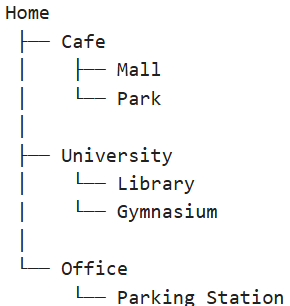



In [ ]:
graph = {
    'Home': ['Cafe', 'University', 'Office'],
    'Cafe': ['Mall', 'Park'],
    'Mall': [],
    'Park': [],
    'University': ['Library', 'Gymnasium'],
    'Library': [],
    'Gymnasium': [],
    'Office': ['Parking Station'],
    'Parking Station': []
}

start_node = 'Home'
goal_node = 'Library'

def solve_bfs():
    queue = [[start_node]]
    explored = set()
    num_explored = 0

    while queue:
        path = queue.pop(0)
        node = path[-1]

        if node in explored:
            continue

        explored.add(node)
        num_explored += 1

        if node == goal_node:
            print("=== BFS Results ===")
            print(f"Path found by BFS: {' -> '.join(path)}")
            print(f"Number of nodes explored: {num_explored}")
            print(f"Length of final path: {len(path) - 1} edges ({len(path)} nodes)")
            return

        for neighbor in graph.get(node, []):
            if neighbor not in explored:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

def solve_dfs():
    stack = [[start_node]]
    explored = set()
    num_explored = 0

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in explored:
            continue

        explored.add(node)
        num_explored += 1

        if node == goal_node:
            print("=== DFS Results ===")
            print(f"Path found by DFS: {' -> '.join(path)}")
            print(f"Number of nodes explored: {num_explored}")
            print(f"Length of final path: {len(path) - 1} edges ({len(path)} nodes)")
            return

        for neighbor in reversed(graph.get(node, [])):
            if neighbor not in explored:
                new_path = list(path)
                new_path.append(neighbor)
                stack.append(new_path)

solve_bfs()
print("-" * 40)
solve_dfs()

**Marking Rubric** 
Section I 
Each Question holds 5 marks
| Component | Marks |
| :--- | :---: |
| Solution | 3 |
| Solved & Dry Run | 2 |

Section II /
For each question with marks 10, the marking will be done according to the following criteria. 

| Component | Marks |
| :--- | :---: |
| BFS | 3 |
| DFS | 3 |
| Solved & Dry Run | 2 |


`Total Marks: 30`\
 Note: AI Generated code will lead to deduction of more than 50% marks